# Smart Insect Identifier using EfficientNetB0

## Nama
Arifa Muthmainnah

## Deskripsi

Project ini bertujuan membangun sistem klasifikasi citra serangga menggunakan metode Transfer Learning dengan arsitektur EfficientNetB0.

Tahapan yang dilakukan:

- Download dataset dari Kaggle
- Pembersihan gambar rusak (Corrupted Images)
- Analisis distribusi dataset
- Resize image menjadi 224 × 224
- Normalisasi pixel
- Data augmentation
- Label encoding otomatis
- Penanganan class imbalance menggunakan Class Weights
- Training model menggunakan EfficientNetB0
- Fine Tuning model
- Evaluasi model
- Export model untuk deployment backend FastAPI

# **1. Install Dependencies**

In [ ]:
!pip install -q kaggle
!pip install -q tensorflow
!pip install -q scikit-learn
!pip install -q seaborn

# **2. Import Libraries**

**Import Library**

In [35]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

from PIL import Image

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    BatchNormalization,
    Dropout,
    Dense
)

from tensorflow.keras.models import (
    Model,
    load_model
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.losses import (
    CategoricalCrossentropy
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.metrics import TopKCategoricalAccuracy

from google.colab import files

# **3. Kaggle Setup**

In [ ]:
SAVE_DIR = "/content/insect_project"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

print(SAVE_DIR)

/content/insect_project


Upload file `kaggle.json` yang diperoleh dari:

Kaggle → Account → Create New API Token

In [ ]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"arifamuthmainnah","key":"9bb71b96a8b0ee08ce372907b0f4ddd6"}'}

In [ ]:
os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# **4. Dataset Loading**

ataset serangga diunduh langsung dari Kaggle dan diekstrak ke lingkungan Colab.

Dataset: https://www.kaggle.com/datasets/baxtiyorbotiraliyev/insects

In [ ]:
!kaggle datasets download \
-d baxtiyorbotiraliyev/insects \
-p /content

Dataset URL: https://www.kaggle.com/datasets/baxtiyorbotiraliyev/insects
License(s): apache-2.0
100% 5.08G/5.08G [04:59<00:00, 18.2MB/s]



In [ ]:
!unzip -q /content/insects.zip -d /content/insects

**Menentukan Path Dataset**

In [36]:
for root, dirs, files in os.walk("/content/insects"):
    print(root)

/content/insects
/content/insects/dataset
/content/insects/dataset/val
/content/insects/dataset/val/small brown plant hopper
/content/insects/dataset/val/leaf beetle
/content/insects/dataset/val/bollworm
/content/insects/dataset/val/rice leaf roller
/content/insects/dataset/val/mosquito
/content/insects/dataset/val/chayon
/content/insects/dataset/val/papilio xuthus
/content/insects/dataset/val/lawana imitata Melichar
/content/insects/dataset/val/wheat sawfly
/content/insects/dataset/val/grub
/content/insects/dataset/val/grain spreader thrips
/content/insects/dataset/val/fly
/content/insects/dataset/val/beet fly
/content/insects/dataset/val/moth
/content/insects/dataset/val/bactrocera tsuneonis
/content/insects/dataset/val/chrysomphalus aonidum
/content/insects/dataset/val/slug
/content/insects/dataset/val/nipaecoccus vastalor
/content/insects/dataset/val/rice gall midge
/content/insects/dataset/val/white backed plant hopper
/content/insects/dataset/val/oides decempunctata
/content/inse

In [37]:
TRAIN_DIR = "/content/insects/dataset/train"
VAL_DIR   = "/content/insects/dataset/val"
TEST_DIR  = "/content/insects/dataset/test"

CLASS_FILE = "/content/insects/dataset/classes.txt"

In [38]:
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(VAL_DIR))
print(os.path.exists(TEST_DIR))

True
True
True


# **5. Data Cleaning & Exploration**

Tahap ini mencakup:

- Pembersihan gambar rusak
- Membaca daftar kelas
- Analisis distribusi data
- Visualisasi contoh gambar

**Pembersihan Gambar Rusak**

In [ ]:
def remove_corrupted_images(folder):

    bad_count = 0

    for root, dirs, files in os.walk(folder):

        for file in files:

            if file.lower().endswith(
                (
                    ".jpg",
                    ".jpeg",
                    ".png",
                    ".bmp",
                    ".webp"
                )
            ):

                path = os.path.join(
                    root,
                    file
                )

                try:

                    img = Image.open(path)
                    img.load()
                    img = img.convert("RGB")
                    img.resize((224,224))

                except:

                    os.remove(path)
                    bad_count += 1

    return bad_count

In [ ]:
bad_train = remove_corrupted_images(TRAIN_DIR)
bad_val   = remove_corrupted_images(VAL_DIR)
bad_test  = remove_corrupted_images(TEST_DIR)

print("Train :", bad_train)
print("Val   :", bad_val)
print("Test  :", bad_test)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


Train : 10
Val   : 3
Test  : 3


# **6. Dataset Analysis**

**Membaca Daftar Kelas**

In [ ]:
with open(CLASS_FILE,"r") as f:

    classes = [
        line.strip()
        for line in f.readlines()
    ]

print("Jumlah kelas:", len(classes))

Jumlah kelas: 118


**Analisis Distribusi Dataset**

In [ ]:
counts = {}

for cls in os.listdir(TRAIN_DIR):

    path = os.path.join(TRAIN_DIR, cls)

    if os.path.isdir(path):

        counts[cls] = len(os.listdir(path))

df_count = pd.DataFrame(
    counts.items(),
    columns=["Class","Count"]
)

df_count.head()

,Class,Count
0,small brown plant hopper,442
1,leaf beetle,4540
2,bollworm,28
3,rice leaf roller,892
4,mosquito,471


**Visualisasi Contoh Gambar**

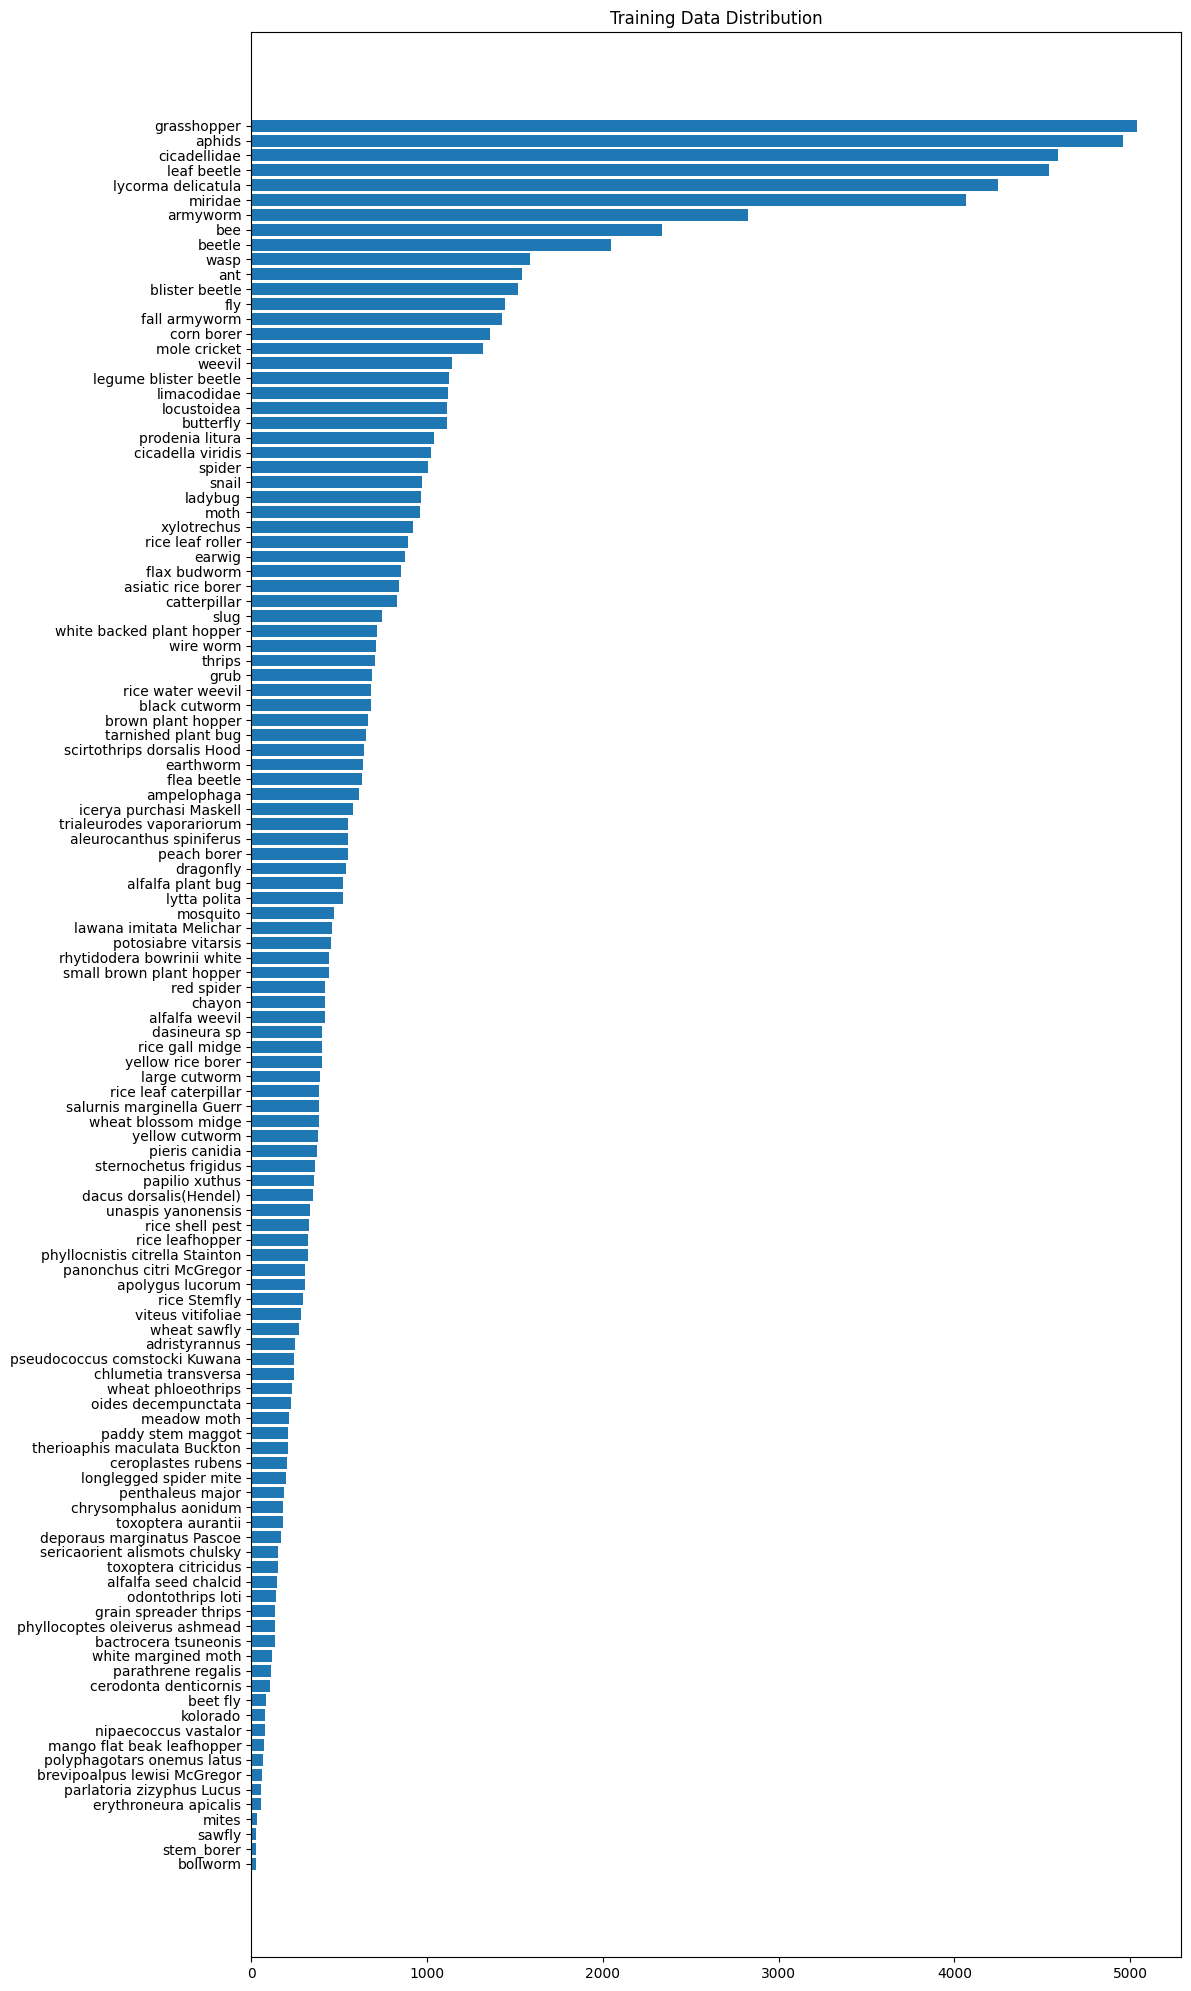

In [ ]:
plt.figure(figsize=(12,25))

df_count = df_count.sort_values(
    "Count"
)

plt.barh(
    df_count["Class"],
    df_count["Count"]
)

plt.title(
    "Training Data Distribution"
)

plt.show()

# **6. Data Preprocessing**

Tahap preprocessing meliputi:

- Resize image menjadi 224 x 224
- Normalisasi pixel
- Data augmentation
- Label encoding otomatis menggunakan flow_from_directory  
- Mengatasi Class Imbalance

**Augmentasi Data**

In [39]:
IMG_SIZE = 224
BATCH_SIZE = 64

In [40]:
train_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

valid_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

**Label Encoding**

In [41]:
train_ds = train_generator.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_ds = valid_generator.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_ds = valid_generator.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 90105 images belonging to 118 classes.
Found 11212 images belonging to 118 classes.
Found 11360 images belonging to 118 classes.


In [42]:
print("Jumlah kelas:", len(train_ds.class_indices))
train_ds.class_indices

Jumlah kelas: 118


{'adristyrannus': 0,
 'aleurocanthus spiniferus': 1,
 'alfalfa plant bug': 2,
 'alfalfa seed chalcid': 3,
 'alfalfa weevil': 4,
 'ampelophaga': 5,
 'ant': 6,
 'aphids': 7,
 'apolygus lucorum': 8,
 'armyworm': 9,
 'asiatic rice borer': 10,
 'bactrocera tsuneonis': 11,
 'bee': 12,
 'beet fly': 13,
 'beetle': 14,
 'black cutworm': 15,
 'blister beetle': 16,
 'bollworm': 17,
 'brevipoalpus lewisi McGregor': 18,
 'brown plant hopper': 19,
 'butterfly': 20,
 'catterpillar': 21,
 'cerodonta denticornis': 22,
 'ceroplastes rubens': 23,
 'chayon': 24,
 'chlumetia transversa': 25,
 'chrysomphalus aonidum': 26,
 'cicadella viridis': 27,
 'cicadellidae': 28,
 'corn borer': 29,
 'dacus dorsalis(Hendel)': 30,
 'dasineura sp': 31,
 'deporaus marginatus Pascoe': 32,
 'dragonfly': 33,
 'earthworm': 34,
 'earwig': 35,
 'erythroneura apicalis': 36,
 'fall armyworm': 37,
 'flax budworm': 38,
 'flea beetle': 39,
 'fly': 40,
 'grain spreader thrips': 41,
 'grasshopper': 42,
 'grub': 43,
 'icerya purchasi Ma

**Handling Class Imbalance**

Menggunakan Class Weights untuk mengurangi bias terhadap kelas mayoritas.

In [43]:
labels = train_ds.classes

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = {
    i: min(float(w), 10.0)
    for i, w in enumerate(weights)
}

class_weights

{0: 3.079039092400219,
 1: 1.3833364038319824,
 2: 1.4572551429680425,
 3: 5.159470911589556,
 4: 1.822438412685571,
 5: 1.2497572748203833,
 6: 0.4961674430898338,
 7: 0.15395195462001093,
 8: 2.511847680642284,
 9: 0.2703972007490277,
 10: 0.9068903740086155,
 11: 5.698520111307867,
 12: 0.3266046599295356,
 13: 9.200020420665714,
 14: 0.37267042211579027,
 15: 1.1180112663473707,
 16: 0.5033630157648347,
 17: 10.0,
 18: 10.0,
 19: 1.1448301273092267,
 20: 0.6866921716863797,
 21: 0.917790498696219,
 22: 7.005520136837195,
 23: 3.706804344248807,
 24: 1.8180992736077481,
 25: 3.129515143095304,
 26: 4.242231638418079,
 27: 0.74643371936975,
 28: 0.16628956770802575,
 29: 0.5622987444147675,
 30: 2.1755034043169634,
 31: 1.8901032052357778,
 32: 4.54524818401937,
 33: 1.4114633917102666,
 34: 1.1987467738073065,
 35: 0.874686935756305,
 36: 10.0,
 37: 0.5351098072286294,
 38: 0.896246120792552,
 39: 1.2101453168229068,
 40: 0.5280786271889725,
 41: 5.53334561532793,
 42: 0.15156841899

In [44]:
print(df_count["Count"].describe())

count     118.000000
mean      763.601695
std      1012.028125
min        28.000000
25%       210.000000
50%       421.500000
75%       867.750000
max      5038.000000
Name: Count, dtype: float64


# **7. Model Training**

Model menggunakan Transfer Learning EfficientNetB0 dengan Early Stopping, Reduce Learning Rate, dan Model Checkpoint.

**Membangun Model**

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE,3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
#Head Model
x = GlobalAveragePooling2D()(
    base_model.output
)

x = BatchNormalization()(x)

x = Dense(
    512,
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = Dropout(0.4)(x)

outputs = Dense(
    len(train_ds.class_indices),
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

**Compile Model**

In [ ]:
loss_fn = "categorical_crossentropy"

model.compile(
    optimizer=Adam(
        learning_rate=1e-3
    ),
    loss=loss_fn,
    metrics=[
        "accuracy",
        TopKCategoricalAccuracy(k=5, name="top5_acc")
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,773,145 (18.21 MB)

 Trainable params: 719,990 (2.75 MB)

 Non-trainable params: 4,053,155 (15.46 MB)

**Callback Training**

In [ ]:
checkpoint = ModelCheckpoint(
    SAVE_DIR + "/best_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    verbose=1
)

**Training Model Tahap 1**

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
  86/1408 ━━━━━━━━━━━━━━━━━━━━ 20:42 940ms/step - accuracy: 0.1055 - loss: 5.0187 - top5_acc: 0.2284

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


 891/1408 ━━━━━━━━━━━━━━━━━━━━ 8:25 977ms/step - accuracy: 0.3153 - loss: 3.3541 - top5_acc: 0.5394

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


1408/1408 ━━━━━━━━━━━━━━━━━━━━ 0s 969ms/step - accuracy: 0.3528 - loss: 3.0761 - top5_acc: 0.5886
Epoch 1: val_loss improved from None to 1.67759, saving model to /content/insect_project/best_model.keras

Epoch 1: finished saving model to /content/insect_project/best_model.keras
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 1471s 1s/step - accuracy: 0.4315 - loss: 2.5017 - top5_acc: 0.6896 - val_accuracy: 0.5715 - val_loss: 1.6776 - val_top5_acc: 0.8173 - learning_rate: 0.0010
Epoch 2/15
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.5187 - loss: 1.8386 - top5_acc: 0.7844
Epoch 2: val_loss improved from 1.67759 to 1.53492, saving model to /content/insect_project/best_model.keras

Epoch 2: finished saving model to /content/insect_project/best_model.keras
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 1354s 962ms/step - accuracy: 0.5252 - loss: 1.8072 - top5_acc: 0.7884 - val_accuracy: 0.5958 - val_loss: 1.5349 - val_top5_acc: 0.8445 - learning_rate: 0.0010
Epoch 3/15
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 0s 933m

**Interpretasi:**  
  
Training tahap 1 telah dilakukan dan disimpan hingga epoch ke-10. Training tidak selesai dikarenakan GPU terkena limit, sehingga akan dilanjutkan menggunakan GPU pada akun Google Colab lain melalui kode di bawah.
  
Selain itu, hasil dari training menunjukkan penurunan val_accuracy pada epoch ke-11, sehingga training tidak dilanjutkan lagi dan langsung ke tahap Fine Tuning

**Load Model Percobaan Training Pertama**

In [ ]:
from google.colab import files

files.upload()

Saving best_model.keras to best_model.keras
Buffered data was truncated after reaching the output size limit.

In [45]:
from tensorflow.keras.models import load_model

model = load_model(
    "SAVE_DIR + "/best_model.keras"
)

In [46]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 6,213,127 (23.70 MB)

 Trainable params: 719,990 (2.75 MB)

 Non-trainable params: 4,053,155 (15.46 MB)

 Optimizer params: 1,439,982 (5.49 MB)

In [47]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)

0 input_layer
1 rescaling
2 normalization
3 rescaling_1
4 stem_conv_pad
5 stem_conv
6 stem_bn
7 stem_activation
8 block1a_dwconv
9 block1a_bn
10 block1a_activation
11 block1a_se_squeeze
12 block1a_se_reshape
13 block1a_se_reduce
14 block1a_se_expand
15 block1a_se_excite
16 block1a_project_conv
17 block1a_project_bn
18 block2a_expand_conv
19 block2a_expand_bn
20 block2a_expand_activation
21 block2a_dwconv_pad
22 block2a_dwconv
23 block2a_bn
24 block2a_activation
25 block2a_se_squeeze
26 block2a_se_reshape
27 block2a_se_reduce
28 block2a_se_expand
29 block2a_se_excite
30 block2a_project_conv
31 block2a_project_bn
32 block2b_expand_conv
33 block2b_expand_bn
34 block2b_expand_activation
35 block2b_dwconv
36 block2b_bn
37 block2b_activation
38 block2b_se_squeeze
39 block2b_se_reshape
40 block2b_se_reduce
41 block2b_se_expand
42 block2b_se_excite
43 block2b_project_conv
44 block2b_project_bn
45 block2b_drop
46 block2b_add
47 block3a_expand_conv
48 block3a_expand_bn
49 block3a_expand_activati

In [48]:
print(len(model.layers))

244


# **8. Fine Tuning**

Pada tahap ini sebagian layer EfficientNetB0 dibuka kembali agar model dapat mempelajari karakteristik spesifik pada dataset serangga.

Fine tuning dilakukan menggunakan learning rate yang lebih kecil untuk menghindari perubahan bobot yang terlalu besar pada model pretrained.

In [49]:
for layer in model.layers[:180]:
    layer.trainable = False

for layer in model.layers[180:]:
    layer.trainable = True

**Compile ulang**

In [53]:
model.compile(
    optimizer=Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        TopKCategoricalAccuracy(k=5, name="top5_acc")
    ]
)

**Callback**

In [54]:
checkpoint = ModelCheckpoint(
    "/content/best_model_ft.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

**Training Fine Tuning**

In [55]:
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/10
  86/1408 ━━━━━━━━━━━━━━━━━━━━ 23:16 1s/step - accuracy: 0.4796 - loss: 1.8172 - top5_acc: 0.7656

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


 891/1408 ━━━━━━━━━━━━━━━━━━━━ 9:24 1s/step - accuracy: 0.4903 - loss: 1.6956 - top5_acc: 0.7739

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


1408/1408 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4994 - loss: 1.6399 - top5_acc: 0.7811
Epoch 1: val_loss improved from None to 1.47967, saving model to /content/best_model_ft.keras

Epoch 1: finished saving model to /content/best_model_ft.keras
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 1641s 1s/step - accuracy: 0.5226 - loss: 1.5108 - top5_acc: 0.7986 - val_accuracy: 0.6104 - val_loss: 1.4797 - val_top5_acc: 0.8571 - learning_rate: 1.0000e-05
Epoch 2/10
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5713 - loss: 1.2694 - top5_acc: 0.8377
Epoch 2: val_loss improved from 1.47967 to 1.37539, saving model to /content/best_model_ft.keras

Epoch 2: finished saving model to /content/best_model_ft.keras
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 1565s 1s/step - accuracy: 0.5840 - loss: 1.2046 - top5_acc: 0.8445 - val_accuracy: 0.6354 - val_loss: 1.3754 - val_top5_acc: 0.8721 - learning_rate: 1.0000e-05
Epoch 3/10
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6099 - loss: 1.0926 - top5_acc:

# **9. Model Evaluation & Export**

Model terbaik hasil training digunakan untuk melakukan evaluasi pada data uji.

Evaluasi dilakukan menggunakan:

- Accuracy
- Classification Report
- Confusion Matrix
- Accuracy Curve
- Loss Curve

**Load Best Model**

In [58]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "/content/best_model_ft.keras"
)

**Prediksi Data Test**

In [59]:
predictions = best_model.predict(
    test_ds
)

pred_labels = np.argmax(
    predictions,
    axis=1
)

true_labels = test_ds.classes

test_loss, test_acc, test_top5 = best_model.evaluate(
    test_ds,
    verbose=1
)

print("Test Accuracy :", test_acc)
print("Top-5 Accuracy:", test_top5)

 28/178 ━━━━━━━━━━━━━━━━━━━━ 35s 237ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


178/178 ━━━━━━━━━━━━━━━━━━━━ 73s 353ms/step
178/178 ━━━━━━━━━━━━━━━━━━━━ 59s 277ms/step - accuracy: 0.6968 - loss: 1.1336 - top5_acc: 0.9024
Test Accuracy : 0.6968309879302979
Top-5 Accuracy: 0.9023767709732056


**Classification Report**

In [60]:
report = classification_report(
    true_labels,
    pred_labels,
    target_names=list(train_ds.class_indices.keys()),
    digits=4
)

print(report)

with open(
    SAVE_DIR + "/classification_report.txt",
    "w"
) as f:
    f.write(report)

                                 precision    recall  f1-score   support

                  adristyrannus     0.5111    0.7188    0.5974        32
       aleurocanthus spiniferus     0.8254    0.7536    0.7879        69
              alfalfa plant bug     0.3267    0.4925    0.3929        67
           alfalfa seed chalcid     0.2222    0.2105    0.2162        19
                 alfalfa weevil     0.3846    0.4717    0.4237        53
                    ampelophaga     0.4872    0.7403    0.5876        77
                            ant     0.8737    0.8964    0.8849       193
                         aphids     0.8404    0.4500    0.5861       620
               apolygus lucorum     0.2949    0.5897    0.3932        39
                       armyworm     0.6867    0.3229    0.4393       353
             asiatic rice borer     0.4771    0.4906    0.4837       106
           bactrocera tsuneonis     0.4737    0.5000    0.4865        18
                            bee     0.9493    0.95

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Gabungkan History Training**

In [61]:
acc = history_ft.history["accuracy"]

val_acc = history_ft.history["val_accuracy"]

loss = history_ft.history["loss"]

val_loss = history_ft.history["val_loss"]

**Simpan Training History**

In [62]:
history_df = pd.DataFrame(history_ft.history)

history_df.to_csv(
    SAVE_DIR + "/training_history.csv",
    index=False
)

**Simpan Model Final**

In [63]:
best_model.save(
    SAVE_DIR + "/final_model.keras"
)

**Simpan Label Mapping**

In [64]:
idx_to_class = {
    v:k
    for k,v in train_ds.class_indices.items()
}

with open(
    SAVE_DIR + "/idx_to_class.json",
    "w"
) as f:

    json.dump(
        idx_to_class,
        f,
        indent=4
    )

**Simpan Metadata**

In [65]:
metadata = {
    "img_size": IMG_SIZE,
    "num_classes": len(train_ds.class_indices)
}

with open(
    SAVE_DIR + "/metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

# **10. Confusion Matrix**

Confusion Matrix digunakan untuk melihat performa model pada setiap kelas serangga.

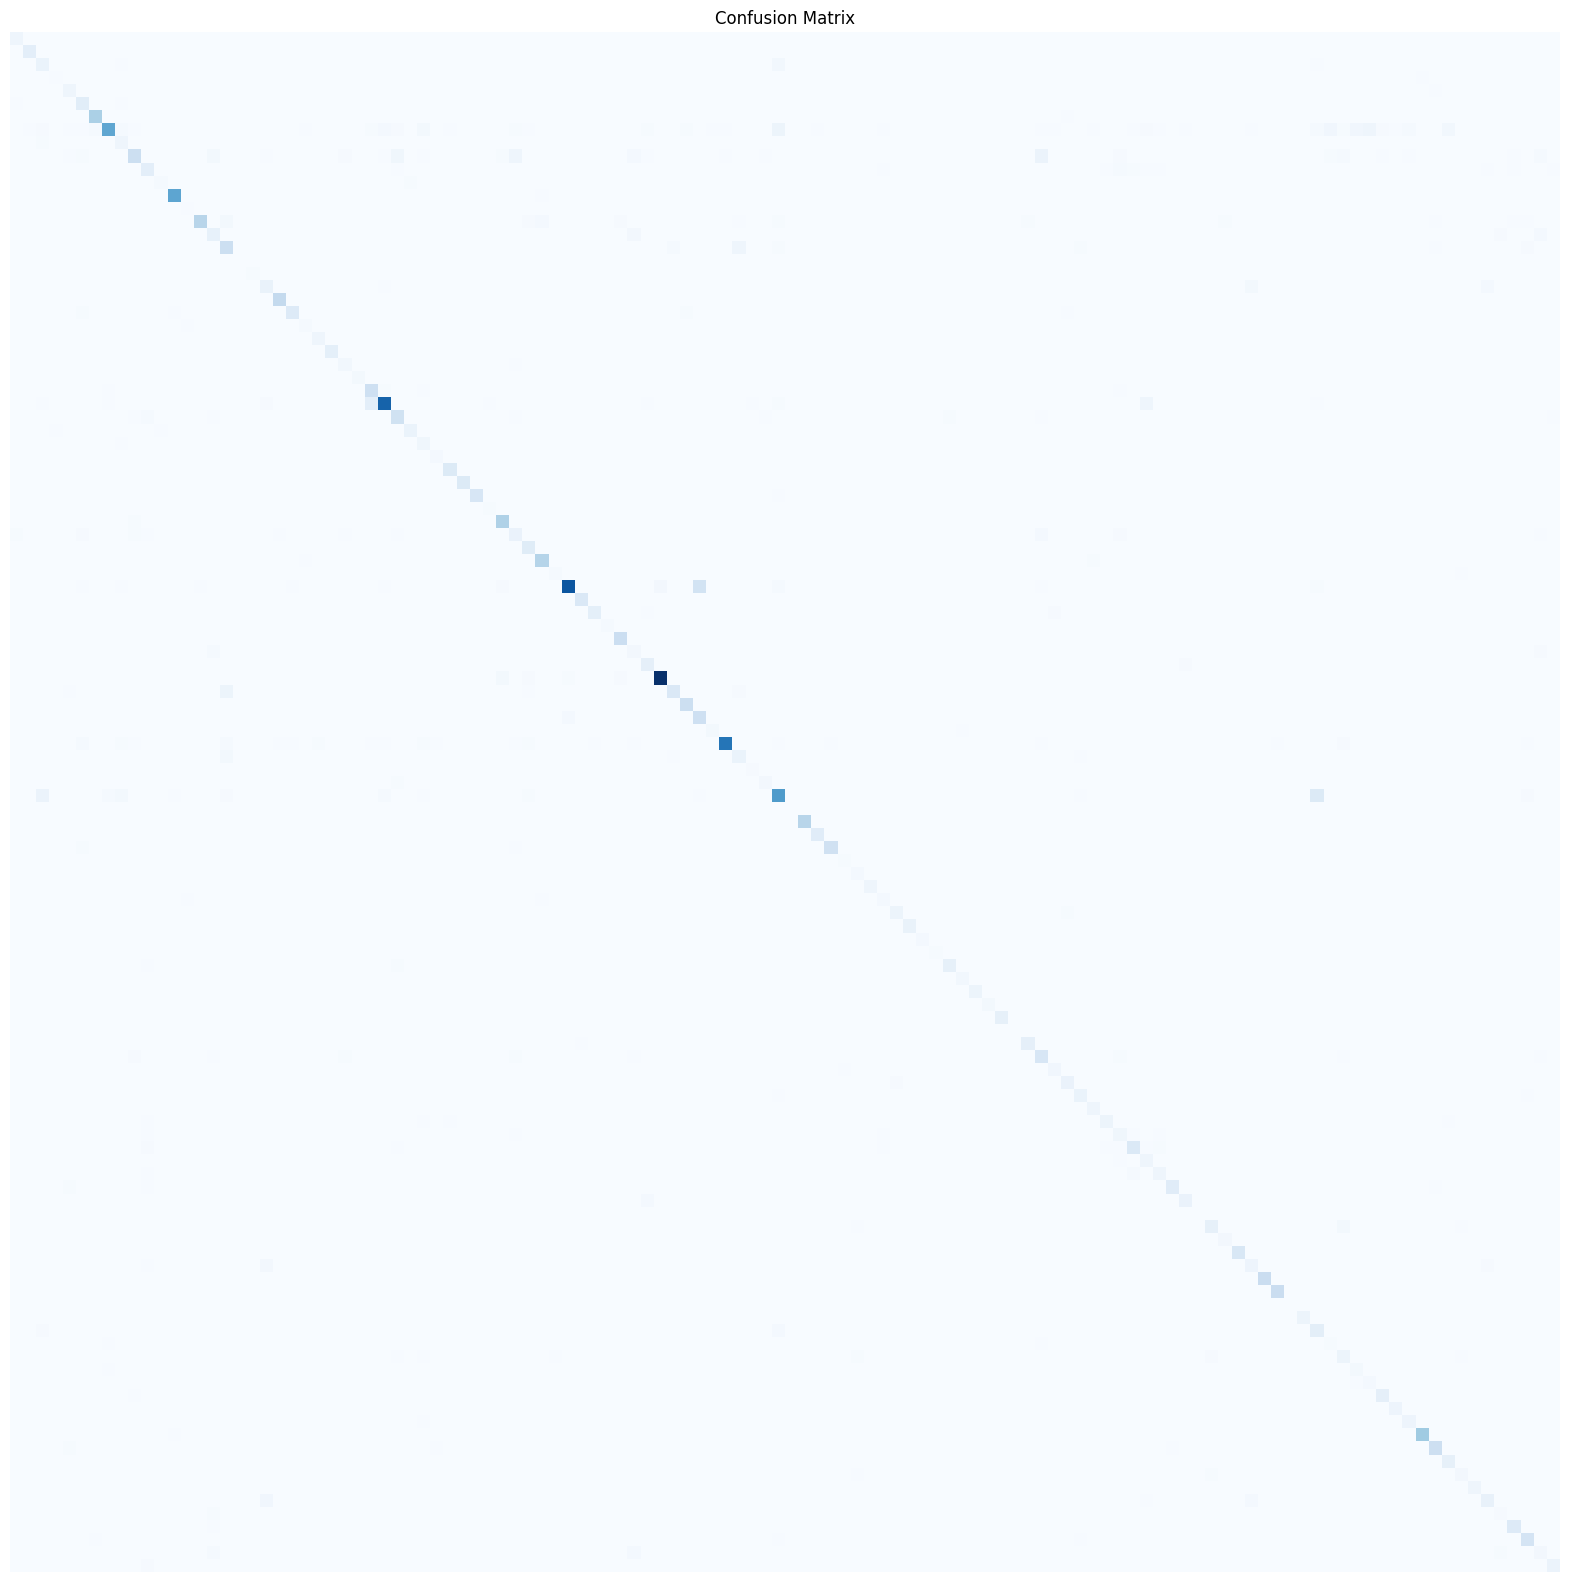

In [66]:
cm = confusion_matrix(
    true_labels,
    pred_labels
)

plt.figure(figsize=(20,20))
sns.heatmap(
    cm,
    cmap="Blues",
    cbar=False,
    xticklabels=False,
    yticklabels=False
)

plt.title("Confusion Matrix")

plt.savefig(
    SAVE_DIR + "/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

# **11. Grafik Accuracy dan Loss**

Visualisasi kurva training digunakan untuk menganalisis proses pembelajaran model dan mendeteksi potensi overfitting maupun underfitting.

**Grafik Accuracy**

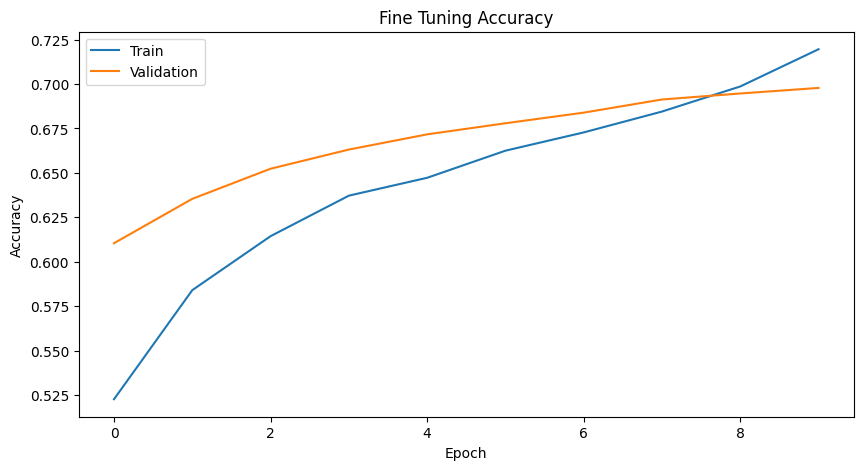

In [67]:
plt.figure(figsize=(10,5))

plt.plot(acc)
plt.plot(val_acc)

plt.title("Fine Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.savefig(
    SAVE_DIR + "/accuracy_curve.png",
    bbox_inches="tight"
)

plt.show()

**Grafik Loss**

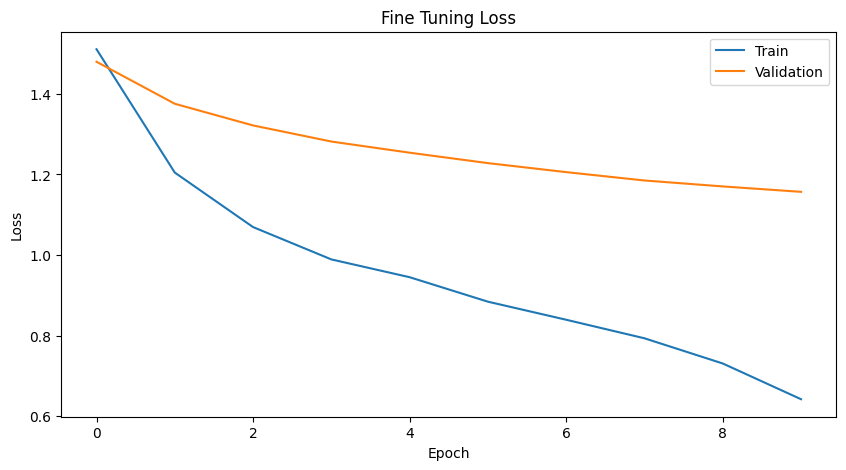

In [68]:
plt.figure(figsize=(10,5))

plt.plot(loss)
plt.plot(val_loss)

plt.title("Fine Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.savefig(
    SAVE_DIR + "/loss_curve.png",
    bbox_inches="tight"
)

plt.show()

**Download Hasil**

In [69]:
!zip -r artifacts.zip $SAVE_DIR

  adding: content/insect_project/ (stored 0%)
  adding: content/insect_project/metadata.json (deflated 11%)
  adding: content/insect_project/final_model.keras (deflated 10%)
  adding: content/insect_project/confusion_matrix.png (deflated 61%)
  adding: content/insect_project/loss_curve.png (deflated 9%)
  adding: content/insect_project/finetuned_model.keras (deflated 10%)
  adding: content/insect_project/classification_report.txt (deflated 68%)
  adding: content/insect_project/training_history.csv (deflated 54%)
  adding: content/insect_project/idx_to_class.json (deflated 59%)
  adding: content/insect_project/accuracy_curve.png (deflated 9%)


In [72]:
from google.colab import files

files.download(
    "artifacts.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>